# Figures for Stromingen Article: gwtransport

This notebook produces the figures for the Stromingen article by Des Tombe (2026):
"gwtransport: tijdreeksanalyse van stoftransport en warmtetransport in grondwater".

- **Afbeelding 1**: Three-panel time series (temperature calibration, residence times, log-removal)
- **Afbeelding 2**: Conceptual diagram (streamlines, gamma distribution, Q vs 2Q)


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import gamma as gamma_dist

from gwtransport import diffusion_fast
from gwtransport import gamma as gamma_utils
from gwtransport.examples import generate_temperature_example_data
from gwtransport.logremoval import parallel_mean, residence_time_to_log_removal
from gwtransport.residence_time import fraction_explained, residence_time
from gwtransport.utils import step_plot_coords

np.random.seed(42)

In [2]:
# Generate synthetic bank filtration data
df, tedges = generate_temperature_example_data(
    date_start="2020-01-01",
    date_end="2025-05-31",
    flow_mean=120.0,
    flow_amplitude=40.0,
    flow_noise=5.0,
    cin_method="soil_temperature",
    aquifer_pore_volume_gamma_mean=8000.0,
    aquifer_pore_volume_gamma_std=400.0,
    aquifer_pore_volume_gamma_nbins=1000,
    measurement_noise=0.05,
)

print(f"Period: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Mean flow: {df['flow'].mean():.1f} m³/day")

Period: 2020-01-01 to 2025-05-31
Mean flow: 103.6 m³/day


## 2. Parameter Estimation via Optimization

We implement inverse modeling to estimate gamma distribution parameters using nonlinear least squares optimization. A spin-up period is excluded to allow thermal breakthrough to stabilize. We use :func:`~gwtransport.residence_time.fraction_explained` to compute the fraction of pore volumes with valid residence times, and exclude the period where the model output is not yet fully informed by the input signal.


In [3]:
# Compute fraction_explained to determine the spin-up period.
# We use the initial parameter guesses (p0) to estimate when the model output
# is fully informed by the input signal. After fitting, we verify that the
# spin-up period was sufficient.
p0_mean, p0_std = 7500.0, 450.0
p0_bins = gamma_utils.bins(mean=p0_mean, std=p0_std, n_bins=25)
rt = residence_time(
    flow=df.flow,
    flow_tedges=tedges,
    aquifer_pore_volumes=p0_bins["expected_values"],
    retardation_factor=2.0,  # Thermal retardation
    direction="extraction_to_infiltration",
)
frac = fraction_explained(rt=rt)

# Find the first date where the model output is fully explained
fully_explained_mask = frac >= 0.99
first_fully_explained = df.index[fully_explained_mask][0]

# Define training dataset excluding the spin-up period
train_data = df.loc[fully_explained_mask].cout
train_data = train_data.dropna()
train_length = len(train_data)

print(f"Spin-up period ends: {first_fully_explained.date()}")
print(f"Training dataset: {train_length} days")
print(f"Training period: {train_data.index[0].date()} to {train_data.index[-1].date()}")

Spin-up period ends: 2020-09-07
Training dataset: 1728 days
Training period: 2020-09-07 to 2025-05-31


In [4]:
def objective(_xdata, mean, std):
    """Infiltration to extraction model for temperature breakthrough with gamma-distributed pore volumes."""
    print(f"Optimizing: mean={mean:.1f} m³, std={std:.1f} m³")

    cout = diffusion_fast.gamma_infiltration_to_extraction(
        cin=df.cin,
        flow=df.flow,
        tedges=tedges,
        cout_tedges=tedges,
        mean=mean,  # Mean pore volume [m³]
        std=std,  # Standard deviation [m³]
        n_bins=25,  # Discretization resolution
        retardation_factor=df.attrs["retardation_factor"],  # Thermal retardation factor
        mean_longitudinal_dispersivity=df.attrs["longitudinal_dispersivity"],  # Longitudinal dispersivity [m]
        mean_molecular_diffusivity=df.attrs["molecular_diffusivity"],  # Molecular diffusion coefficient [m²/day]
        mean_streamline_length=df.attrs[
            "streamline_length"
        ],  # Streamline length. Needed for computation of diffusion coefficients [m].
    )

    # Return training period data (excluding spin-up)
    return cout[fully_explained_mask]

In [5]:
# Nonlinear least squares optimization
print("Starting parameter optimization...")

(mean_fitted, std_fitted), pcov = curve_fit(
    objective,
    df.index,
    train_data.values,
    p0=(7500.0, 450.0),  # Initial parameter estimates [m³]
    bounds=([5000, 200], [10000, 600]),  # Physical constraints [m³]
    method="trf",  # Trust Region Reflective algorithm
    max_nfev=250,  # Limit function evaluations
)

print("\nOptimization completed!")

Starting parameter optimization...
Optimizing: mean=7500.0 m³, std=450.0 m³


/Users/bdestombe/Projects/gwtransport/gwtransport/src/gwtransport/diffusion_fast.py:596: UserWarning: Using multiple aquifer_pore_volumes with non-zero mean_longitudinal_dispersivity. Both represent spreading from velocity heterogeneity at different scales.

This is appropriate when:
  - APVD comes from streamline analysis (explicit geometry)
  - You want to add unresolved microdispersion and molecular diffusion

This may double-count spreading when:
  - APVD was calibrated from measurements (microdispersion already included)

For gamma-parameterized APVD, consider using the 'equivalent APVD std' approach
from 05_Diffusion_Dispersion.ipynb to combine both effects in the faster advection
module. Note: this variance combination is only valid for continuous (gamma)
distributions, not for discrete streamline volumes.
Suppress this warning with suppress_dispersion_warning=True.
  return infiltration_to_extraction(


Optimizing: mean=7500.0 m³, std=450.0 m³


Optimizing: mean=7500.0 m³, std=450.0 m³


Optimizing: mean=7873.9 m³, std=508.1 m³


...

Optimizing: mean=8000.1 m³, std=401.1 m³


Optimizing: mean=8000.1 m³, std=401.1 m³


Optimizing: mean=8000.1 m³, std=401.1 m³


Optimizing: mean=8000.1 m³, std=401.1 m³



Optimization completed!


In [6]:
# Generate model predictions using optimized parameters
df["cout_modeled"] = diffusion_fast.gamma_infiltration_to_extraction(
    cin=df.cin,
    flow=df.flow,
    tedges=tedges,
    cout_tedges=tedges,
    mean=mean_fitted,  # Fitted mean pore volume
    std=std_fitted,  # Fitted standard deviation
    n_bins=250,  # High computational resolution
    retardation_factor=df.attrs["retardation_factor"],  # Thermal retardation
    mean_longitudinal_dispersivity=df.attrs["longitudinal_dispersivity"],  # Longitudinal dispersivity [m]
    mean_molecular_diffusivity=df.attrs["molecular_diffusivity"],  # Molecular diffusion coefficient [m²/day]
    mean_streamline_length=df.attrs[
        "streamline_length"
    ],  # Streamline length. Needed for computation of diffusion coefficients [m].
)

# diffusion_fast is also used by generating the example data
# The exact solution can be computed using the diffusion module, but it takes 15~30 for a single timeseries, so we skip it here for efficiency. The diffusion module is used in the test suite to verify that diffusion_fast produces consistent results.
# df["cout_modeled_exact"] = diffusion.gamma_infiltration_to_extraction(
#     cin=df.cin,
#     flow=df.flow,
#     tedges=tedges,
#     cout_tedges=tedges,
#     mean=mean_fitted,  # Fitted mean pore volume
#     std=std_fitted,  # Fitted standard deviation
#     n_bins=250,  # High computational resolution
#     retardation_factor=df.attrs["retardation_factor"],  # Thermal retardation
#     mean_longitudinal_dispersivity=df.attrs["longitudinal_dispersivity"],  # Longitudinal dispersivity [m]
#     mean_molecular_diffusivity=df.attrs["molecular_diffusivity"],  # Molecular diffusion coefficient [m²/day]
#     mean_streamline_length=df.attrs["streamline_length"],  # Streamline length. Needed for computation of diffusion coefficients [m].
# )

# Report optimization results with uncertainty estimates
print("Parameter Estimation Results:")
print(
    "Note: 100% fit is not achievable due to the measurement noise on the temperature measurements. See `measurement_noise` parameter in `generate_temperature_example_data`."
)
print(f"Mean pore volume: {mean_fitted:.1f} ± {pcov[0, 0] ** 0.5:.1f} m³")
print(f"Standard deviation: {std_fitted:.1f} ± {pcov[1, 1] ** 0.5:.1f} m³")
print(f"Coefficient of variation: {std_fitted / mean_fitted:.2f}")

# Compare with true values
true_mean = df.attrs["aquifer_pore_volume_gamma_mean"]
true_std = df.attrs["aquifer_pore_volume_gamma_std"]
print(f"\nTrue values: {true_mean:.1f} m³ (mean), {true_std:.1f} m³ (std)")
print(
    f"Relative error: {abs(mean_fitted - true_mean) / true_mean * 100:.1f}% (mean), {abs(std_fitted - true_std) / true_std * 100:.1f}% (std)"
)

Parameter Estimation Results:
Note: 100% fit is not achievable due to the measurement noise on the temperature measurements. See `measurement_noise` parameter in `generate_temperature_example_data`.
Mean pore volume: 8000.1 ± 0.8 m³
Standard deviation: 401.1 ± 1.5 m³
Coefficient of variation: 0.05

True values: 8000.0 m³ (mean), 400.0 m³ (std)
Relative error: 0.0% (mean), 0.3% (std)


In [7]:
# Compute residence times
bins = gamma_utils.bins(mean=mean_fitted, std=std_fitted, n_bins=1000)

rt_water = residence_time(
    flow=df.flow,
    flow_tedges=tedges,
    aquifer_pore_volumes=bins["expected_values"],
    retardation_factor=1.0,
    direction="extraction_to_infiltration",
)

rt_thermal = residence_time(
    flow=df.flow,
    flow_tedges=tedges,
    aquifer_pore_volumes=bins["expected_values"],
    retardation_factor=2.0,
    direction="extraction_to_infiltration",
)

# Residence time statistics
quantiles = [1, 10, 90, 99]
with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message="Mean of empty slice")
    warnings.filterwarnings(action="ignore", message="All-NaN slice encountered")
    df["rt_water_mean"] = np.nanmean(rt_water, axis=0)
    df["rt_thermal_mean"] = np.nanmean(rt_thermal, axis=0)
    for q in quantiles:
        df[f"rt_water_{q}%"] = np.nanpercentile(rt_water, q, axis=0)

# Fraction of output concentration explained by input signal
frac_explained = fraction_explained(rt=rt_water)

# Compute log-removal: two-component model
# 1. Inactivation (time-dependent): MS2 at 10 deg C from Schijven & Hassanizadeh (2000) Table 7
#    ln(mu_l) = 0.12 * T + (-3.5), at T=10: mu_l = exp(-2.3) = 0.10 day^-1
#    mu_log10 = 0.10 / ln(10) = 0.043 log10/day
log10_decay_rate = np.exp(0.12 * 10 - 3.5) / np.log(10)  # MS2 at 10 deg C

# 2. Attachment (geometry-dependent): user-specified constant
#    At Castricum, Schijven et al. (1999) observed ~8 log10 total removal in 30m/25d
#    Inactivation contribution: ~0.3 log10 -> Attachment: ~7.7 log10
lr_attachment = 7.0  # log10 (conservative estimate for attachment)

rt_water_forward = residence_time(
    flow=df.flow,
    flow_tedges=tedges,
    aquifer_pore_volumes=bins["expected_values"],
    retardation_factor=1.0,
    direction="infiltration_to_extraction",
)
log_removal_decay_array = residence_time_to_log_removal(
    residence_times=rt_water_forward,
    log10_decay_rate=log10_decay_rate,
)
df["lr_decay"] = parallel_mean(log_removals=log_removal_decay_array, axis=0)
df["lr_total"] = df["lr_decay"] + lr_attachment

print(f"MS2 inactivation rate: {log10_decay_rate:.4f} log10/day at 10 deg C")
print(f"Attachment (constant): {lr_attachment:.1f} log10")
print(f"Inactivation range: {df['lr_decay'].min():.2f} - {df['lr_decay'].max():.2f} log10")
print(f"Total removal range: {df['lr_total'].min():.2f} - {df['lr_total'].max():.2f} log10")
print("All computations completed.")

MS2 inactivation rate: 0.0435 log10/day at 10 deg C
Attachment (constant): 7.0 log10
Inactivation range: 2.18 - 7.16 log10
Total removal range: 9.18 - 14.16 log10
All computations completed.


## Afbeelding 1: Time Series Results

Three-panel figure: temperature calibration (top), residence time distribution (middle),
and log-removal (bottom).


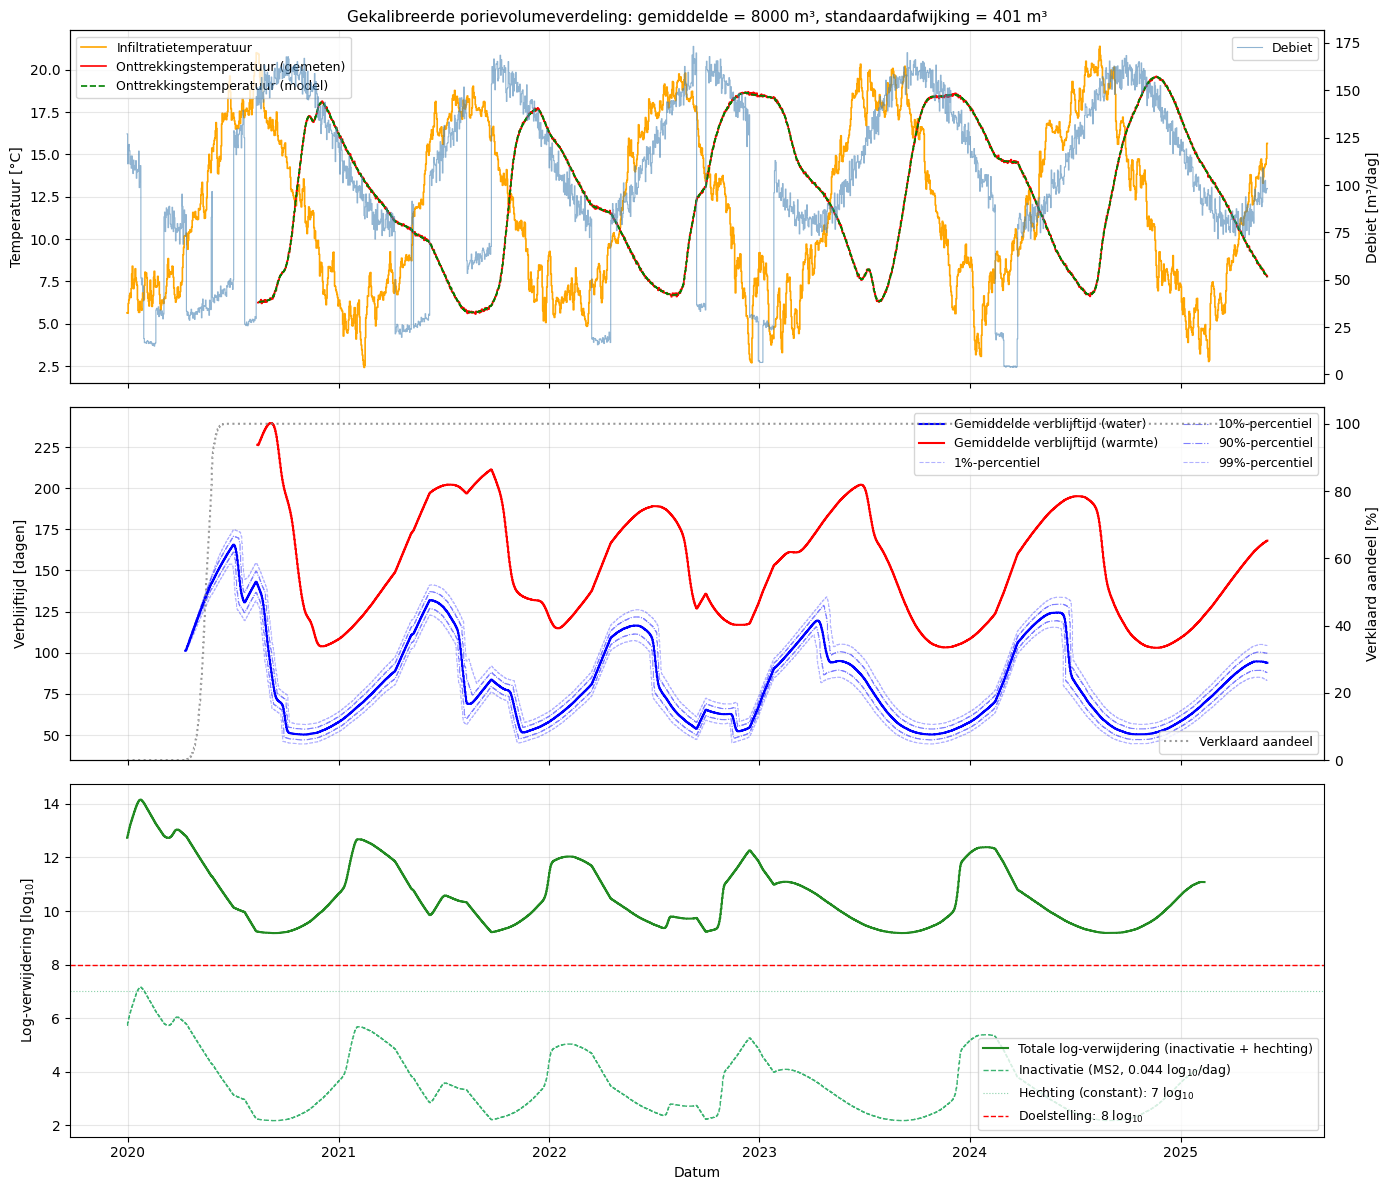


Manuscript numbers:
  MS2 inactivation rate: 0.044 log10/day at 10 deg C
  Attachment (constant): 7 log10
  Total removal range: 9.2 - 14.2 log10
  Days achieving 8 log10 target: 1869/1869 (100.0%)
  Mean total removal: 10.5 log10
  Mean inactivation: 3.55 log10


In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Top panel: Temperature and flow ---
ax1.plot(*step_plot_coords(tedges, df.cin), color="orange", lw=1.2, label="Infiltratietemperatuur")
ax1.plot(*step_plot_coords(tedges, df.cout), color="red", lw=1.2, label="Onttrekkingstemperatuur (gemeten)")
ax1.plot(
    *step_plot_coords(tedges, df.cout_modeled),
    color="green",
    lw=1.2,
    ls="--",
    label="Onttrekkingstemperatuur (model)",
)
ax1.set_ylabel("Temperatuur [°C]")
ax1.legend(loc="upper left", fontsize=9)

ax1b = ax1.twinx()
ax1b.plot(*step_plot_coords(tedges, df.flow), color="steelblue", lw=0.8, alpha=0.6, label="Debiet")
ax1b.set_ylabel("Debiet [m³/dag]")
ax1b.legend(loc="upper right", fontsize=9)

ax1.set_title(
    f"Gekalibreerde porievolumeverdeling: gemiddelde = {mean_fitted:.0f} m³, standaardafwijking = {std_fitted:.0f} m³",
    fontsize=11,
)

# --- Middle panel: Residence time distribution ---
xstep_rt, ystep_rt_water = step_plot_coords(tedges, df.rt_water_mean)
ax2.plot(xstep_rt, ystep_rt_water, color="blue", lw=1.5, label="Gemiddelde verblijftijd (water)")
ax2.plot(*step_plot_coords(tedges, df.rt_thermal_mean), color="red", lw=1.5, label="Gemiddelde verblijftijd (warmte)")

for q in quantiles:
    alpha_val = 0.5 if q in {10, 90} else 0.3
    ls = "--" if q in {1, 99} else "-."
    ax2.plot(
        *step_plot_coords(tedges, df[f"rt_water_{q}%"]),
        color="blue",
        alpha=alpha_val,
        lw=0.8,
        ls=ls,
        label=f"{q}%-percentiel",
    )

ax2.set_ylabel("Verblijftijd [dagen]")
ax2.legend(loc="upper right", fontsize=9, ncol=2)

# Second y-axis: fraction explained
ax2b = ax2.twinx()
ax2b.plot(
    *step_plot_coords(tedges, frac_explained * 100), color="gray", lw=1.5, ls=":", alpha=0.8, label="Verklaard aandeel"
)
ax2b.set_ylabel("Verklaard aandeel [%]")
ax2b.set_ylim(0, 105)
ax2b.legend(loc="lower right", fontsize=9)

# --- Bottom panel: Log-removal (two-component model) ---
ax3.plot(
    *step_plot_coords(tedges, df.lr_total),
    color="forestgreen",
    lw=1.5,
    label="Totale log-verwijdering (inactivatie + hechting)",
)
ax3.plot(
    *step_plot_coords(tedges, df.lr_decay),
    color="mediumseagreen",
    lw=1.0,
    ls="--",
    label=f"Inactivatie (MS2, {log10_decay_rate:.3f} log$_{{10}}$/dag)",
)
ax3.axhline(
    y=lr_attachment,
    color="mediumseagreen",
    ls=":",
    lw=0.8,
    alpha=0.6,
    label=f"Hechting (constant): {lr_attachment:.0f} log$_{{10}}$",
)
ax3.axhline(y=8.0, color="red", ls="--", lw=1.0, label="Doelstelling: 8 log$_{10}$")
ax3.set_ylabel("Log-verwijdering [log$_{10}$]")
ax3.set_xlabel("Datum")
ax3.legend(loc="lower right", fontsize=9)

for ax in (ax1, ax2, ax3):
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics for manuscript
target = 8.0
days_above = (df["lr_total"] >= target).sum()
days_total = df["lr_total"].notna().sum()
pct_above = 100 * days_above / days_total
print("\nManuscript numbers:")
print(f"  MS2 inactivation rate: {log10_decay_rate:.3f} log10/day at 10 deg C")
print(f"  Attachment (constant): {lr_attachment:.0f} log10")
print(f"  Total removal range: {df['lr_total'].min():.1f} - {df['lr_total'].max():.1f} log10")
print(f"  Days achieving {target:.0f} log10 target: {days_above}/{days_total} ({pct_above:.1f}%)")
print(f"  Mean total removal: {df['lr_total'].mean():.1f} log10")
print(f"  Mean inactivation: {df['lr_decay'].mean():.2f} log10")

## Afbeelding 2: Conceptual Diagram

Three-panel conceptual figure: streamlines (left), gamma distribution (middle),
and Q vs 2Q illustration (right).


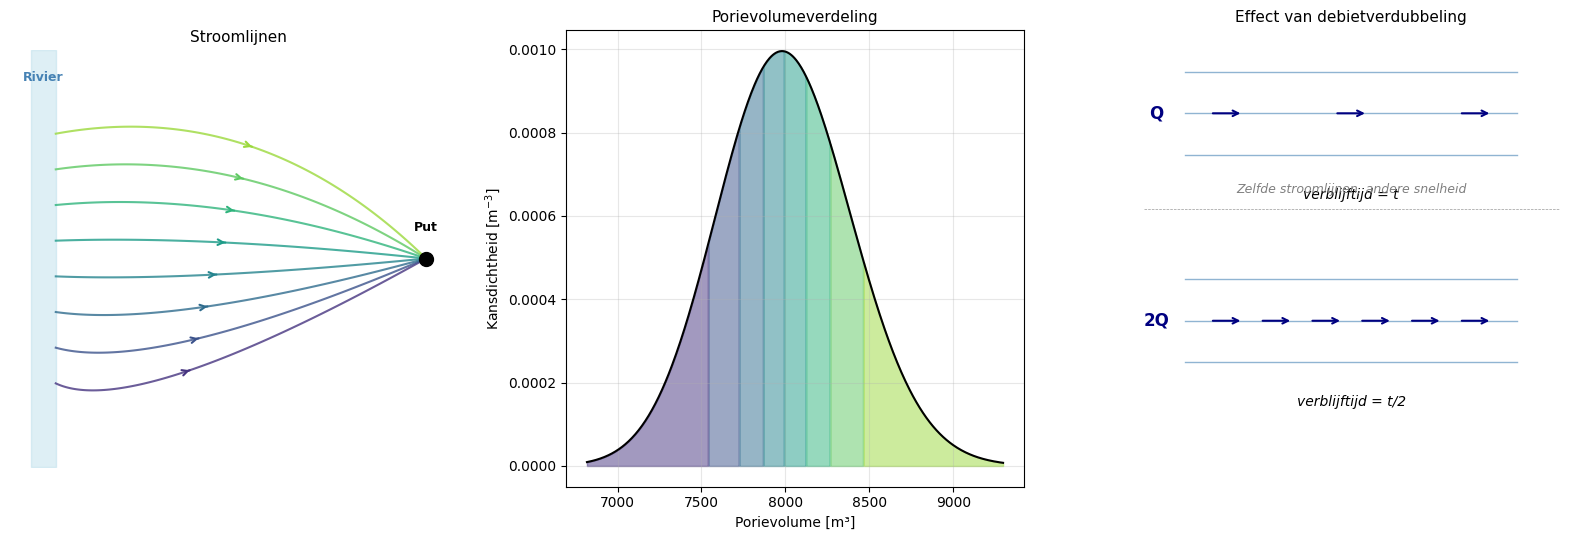

In [9]:
# Prepare gamma distribution for middle panel
n_tubes = 8
vis_bins = gamma_utils.bins(mean=mean_fitted, std=std_fitted, n_bins=n_tubes)
alpha_g, beta_g = gamma_utils.mean_std_loc_to_alpha_beta(mean=mean_fitted, std=std_fitted)
cmap = plt.colormaps["viridis"](np.linspace(0.15, 0.85, n_tubes))

fig, (ax_left, ax_mid, ax_right) = plt.subplots(1, 3, figsize=(16, 5.5))

# ========================
# Left panel: Streamlines
# ========================
ax_left.set_xlim(-0.5, 10.5)
ax_left.set_ylim(-1.5, 8.5)
ax_left.set_aspect("equal")
ax_left.axis("off")
ax_left.set_title("Stroomlijnen", fontsize=11)

# Infiltration zone (river bank) on the left
ax_left.fill_between([0, 0.6], -1.5, 8.5, color="lightblue", alpha=0.4)
ax_left.text(0.3, 8.0, "Rivier", ha="center", va="top", fontsize=9, color="steelblue", fontweight="bold")

# Extraction well
well_x, well_y = 9.5, 3.5
ax_left.plot(well_x, well_y, "ko", markersize=10, zorder=5)
ax_left.text(well_x, well_y + 0.6, "Put", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Draw curved streamlines from river to well
infiltration_y = np.linspace(0.5, 6.5, n_tubes)
for i, y0 in enumerate(infiltration_y):
    # Quadratic Bezier-like curve from (0.6, y0) to (well_x, well_y)
    t = np.linspace(0, 1, 100)
    # Control point shifts the curve
    ctrl_x = 4.0 + 1.5 * (y0 - 3.5) / 3.0
    ctrl_y = y0 + 0.3 * (y0 - 3.5)
    x_curve = (1 - t) ** 2 * 0.6 + 2 * (1 - t) * t * ctrl_x + t**2 * well_x
    y_curve = (1 - t) ** 2 * y0 + 2 * (1 - t) * t * ctrl_y + t**2 * well_y
    ax_left.plot(x_curve, y_curve, color=cmap[i], lw=1.5, alpha=0.8)
    # Arrowhead at midpoint
    mid = len(t) // 2
    dx = x_curve[mid + 1] - x_curve[mid - 1]
    dy = y_curve[mid + 1] - y_curve[mid - 1]
    ax_left.annotate(
        "",
        xy=(x_curve[mid] + dx * 0.01, y_curve[mid] + dy * 0.01),
        xytext=(x_curve[mid] - dx * 0.01, y_curve[mid] - dy * 0.01),
        arrowprops={"arrowstyle": "->", "color": cmap[i], "lw": 1.5},
    )

# ===================================
# Middle panel: Gamma distribution
# ===================================
ax_mid.set_title("Porievolumeverdeling", fontsize=11)

x_gamma = np.linspace(
    gamma_dist.ppf(0.001, alpha_g, scale=beta_g),
    gamma_dist.ppf(0.999, alpha_g, scale=beta_g),
    500,
)
y_gamma = gamma_dist.pdf(x_gamma, alpha_g, scale=beta_g)

# Fill each bin with the corresponding streamtube color
for i in range(n_tubes):
    lo = vis_bins["lower_bound"][i]
    hi = vis_bins["upper_bound"][i]
    if np.isinf(hi):
        hi = x_gamma[-1]
    if np.isinf(lo) or lo < x_gamma[0]:
        lo = x_gamma[0]
    mask = (x_gamma >= lo) & (x_gamma <= hi)
    ax_mid.fill_between(x_gamma[mask], y_gamma[mask], color=cmap[i], alpha=0.5)

ax_mid.plot(x_gamma, y_gamma, "k-", lw=1.5)
ax_mid.set_xlabel("Porievolume [m³]")
ax_mid.set_ylabel("Kansdichtheid [m$^{-3}$]")
ax_mid.grid(True, alpha=0.3)

# ====================================
# Right panel: Q vs 2Q illustration
# ====================================
ax_right.set_xlim(-0.5, 10.5)
ax_right.set_ylim(-2.5, 8.5)
ax_right.set_aspect("equal")
ax_right.axis("off")
ax_right.set_title("Effect van debietverdubbeling", fontsize=11)

# Draw two scenarios side by side (top = Q, bottom = 2Q)
for scenario_idx, (label, y_offset, n_arrows) in enumerate([("Q", 5.0, 3), ("2Q", 0.0, 6)]):
    y_base = y_offset
    # Simple horizontal streamlines
    stream_ys = np.linspace(y_base + 0.5, y_base + 2.5, 3)
    for sy in stream_ys:
        ax_right.plot([1, 9], [sy, sy], color="steelblue", lw=1.0, alpha=0.6)

    # Arrows showing velocity
    arrow_xs = np.linspace(2, 8, n_arrows)
    for ax_pos in arrow_xs:
        ax_right.annotate(
            "",
            xy=(ax_pos + 0.4, y_base + 1.5),
            xytext=(ax_pos - 0.4, y_base + 1.5),
            arrowprops={"arrowstyle": "->", "color": "navy", "lw": 1.5},
        )

    # Label
    ax_right.text(0.3, y_base + 1.5, label, ha="center", va="center", fontsize=12, fontweight="bold", color="navy")

    # Residence time annotation
    rt_label = "t" if scenario_idx == 0 else "t/2"
    ax_right.text(
        5.0,
        y_base - 0.3,
        f"verblijftijd = {rt_label}",
        ha="center",
        va="top",
        fontsize=10,
        fontstyle="italic",
    )

# Separating line
ax_right.plot([0, 10], [4.2, 4.2], "k--", lw=0.5, alpha=0.4)
ax_right.text(
    5.0,
    4.5,
    "Zelfde stroomlijnen, andere snelheid",
    ha="center",
    va="bottom",
    fontsize=9,
    fontstyle="italic",
    color="gray",
)

plt.tight_layout()
plt.show()